<a href="https://colab.research.google.com/github/Codewithtanvi/House-Price-Prediction-/blob/main/Day4_Fund_Performance_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [3]:
import zipfile
from io import BytesIO

zip_file_path = '/content/drive/MyDrive/Bluestock Internship/Datasets/drive-download-20260603T142152Z-3-001.zip'
csv_file_in_zip = '02_nav_history.csv'

try:
    with zipfile.ZipFile(zip_file_path, 'r') as z:
        with z.open(csv_file_in_zip) as f:
            df = pd.read_csv(f)
    print("DataFrame loaded successfully:")
    df.head()
except FileNotFoundError:
    print(f"Error: ZIP file not found at {zip_file_path}")
except KeyError:
    print(f"Error: '{csv_file_in_zip}' not found inside the ZIP file. Please check the file name.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

DataFrame loaded successfully:


In [5]:
nav = df.copy() # Use the already loaded df DataFrame

nav['date'] = pd.to_datetime(nav['date'])

In [7]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

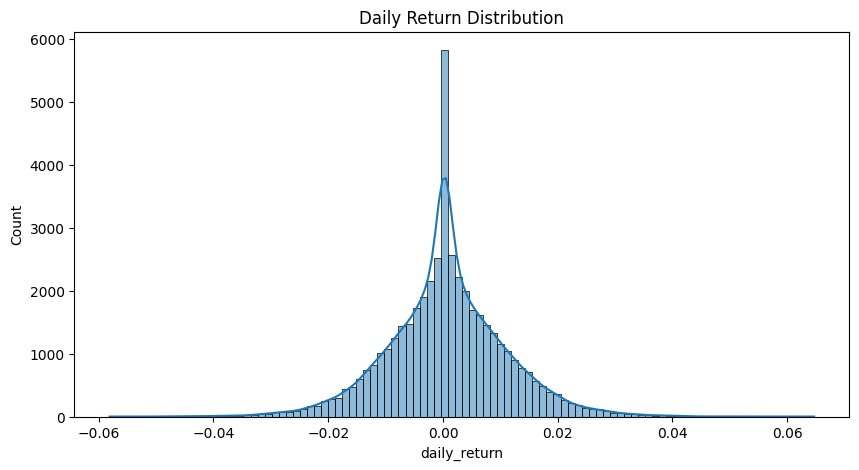

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")
plt.show()

In [9]:
nav['daily_return'].describe()

,daily_return
count,45960.000000
mean,0.000631
std,0.010290
min,-0.058102
25%,-0.005042
50%,0.000340
75%,0.006324
max,0.064713


In [10]:
def cagr(start_nav,end_nav,years):

    return (
        (end_nav/start_nav)
        ** (1/years)
    ) - 1

In [12]:
cagr_table = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ].sort_values('date')

    start = temp['nav'].iloc[0]
    end = temp['nav'].iloc[-1]

    cagr_5 = cagr(start,end,5)

    cagr_table.append(
        [fund,cagr_5]
    )

cagr_df = pd.DataFrame(
    cagr_table,
    columns=[
        'fund',
        'cagr_5y'
    ]
)

cagr_df.head()

,fund,cagr_5y
0,100016,0.023168
1,100025,0.039127
2,100033,0.260741
3,101206,0.204427
4,101207,0.069533


In [13]:
rf = 0.065

In [15]:
sharpe_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    mean_return = (
        temp['daily_return']
        .mean()*252
    )

    vol = (
        temp['daily_return']
        .std()
    )

    sharpe = (
        (mean_return-rf)
        /vol
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'fund',
        'sharpe_ratio'
    ]
)

sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head()

,fund,sharpe_ratio
34,148567,364.969375
30,120843,329.299480
36,148569,311.202366
19,119551,304.483175
25,120505,297.385502


In [17]:
sortino_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    downside = temp[
        temp['daily_return']<0
    ]['daily_return']

    downside_std = downside.std()

    annual_return = (
        temp['daily_return']
        .mean()*252
    )

    sortino = (
        (annual_return-rf)
        /downside_std
    )*np.sqrt(252)

    sortino_results.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'fund',
        'sortino_ratio'
    ]
)

In [20]:
import os

# List contents of Google Drive root
drive_path = '/content/drive/MyDrive'
print(f"Contents of {drive_path}:")
print(os.listdir(drive_path))

Contents of /content/drive/MyDrive:
['Colab Notebooks', 'project_2.py', 'LOGO.png', 'wetransfer_project-file_2024-05-29_0929.zip', 'Types Of Dals Collection', 'images of number plate', 'SUPERMARKET GROCERY SALES- RETAIL ANALYSIS.pptx', 'Laptop Price Analysis.pptx', 'Resume (2) (2).pdf', 'Resume (2) (1).pdf', 'Documents', 'Certificates', 'Research Paper', 'Aptitute by Raman Tiwari.docx', 'Cognifz offer letter.pdf', 'Task Completed (1).zip', 'Task Completed.zip', 'Fees Receipt (1).jpg', 'Fees Receipt.jpg', 'Screenshot_20250731_110150_YouTube.jpg', 'Screenshot_20250820_123613_PhonePe.jpg', 'Resume (2).pdf', 'CV (6).pdf', 'CV (5).pdf', 'Document from Tanii.pdf', 'CV (4).pdf', 'CV (3).pdf', 'CV (2).pdf', 'CV (1).pdf', 'CV.pdf', 'urbanthreads_q4.csv', 'urbanthreads_q4 (2).gsheet', 'urbanthreads_q4 (1).gsheet', 'urbanthreads_q4.gsheet', 'Raw_data.gsheet', 'Cleaning_Log.gsheet', 'RBI+GRADE+B+PYQ+(1).pdf', 'Bluestock Internship']


In [22]:
import zipfile
from io import BytesIO

zip_file_path = '/content/drive/MyDrive/Bluestock Internship/Datasets/drive-download-20260603T142152Z-3-001.zip'
csv_file_in_zip = 'nifty100.csv'

try:
    with zipfile.ZipFile(zip_file_path, 'r') as z:
        with z.open(csv_file_in_zip) as f:
            df = pd.read_csv(f)
    print("DataFrame loaded successfully:")
    df.head()
except FileNotFoundError:
    print(f"Error: ZIP file not found at {zip_file_path}")
except KeyError:
    print(f"Error: '{csv_file_in_zip}' not found inside the ZIP file. Please check the file name.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Error: 'nifty100.csv' not found inside the ZIP file. Please check the file name.


In [24]:
nifty = pd.read_csv(
    "/content/drive/MyDrive/Bluestock Internship/10_benchmark_indices.csv"
)

nifty['date'] = pd.to_datetime(
    nifty['date']
)

nifty['benchmark_return'] = (
    nifty['close_value']
    .pct_change()
)

In [27]:
alpha_beta = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ][['date','daily_return']]

    merged = pd.merge(
        temp,
        nifty[
            ['date',
             'benchmark_return']
        ],
        on='date'
    )

    # Drop rows with NaN in either column before passing to linregress
    valid_data = merged.dropna(subset=['benchmark_return', 'daily_return'])

    # Ensure there's enough data after dropping NaNs for linregress
    if len(valid_data) > 1: # linregress requires at least 2 data points
        slope, intercept, r, p, se = linregress(
            valid_data['benchmark_return'],
            valid_data['daily_return']
        )

        beta = slope

        alpha = intercept*252

        alpha_beta.append(
            [fund,
             alpha,
             beta]
        )
    else:
        # Handle cases where there isn't enough valid data for regression
        alpha_beta.append(
            [fund,
             None, # or np.nan
             None] # or np.nan
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'fund',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,fund,alpha,beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [28]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [30]:
drawdown_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ].copy()

    temp['running_max'] = (
        temp['nav']
        .cummax()
    )

    temp['drawdown'] = (
        temp['nav']
        /temp['running_max']
    )-1

    mdd = temp[
        'drawdown'
    ].min()

    drawdown_results.append(
        [fund,mdd]
    )

mdd_df = pd.DataFrame(
    drawdown_results,
    columns=[
        'fund',
        'max_drawdown'
    ]
)

In [31]:
score = cagr_df.merge(
    sharpe_df,
    on='fund'
)

score = score.merge(
    alpha_beta_df,
    on='fund'
)

score = score.merge(
    mdd_df,
    on='fund'
)

In [32]:
score['return_rank'] = (
    score['cagr_5y']
    .rank(
        ascending=False
    )
)

score['sharpe_rank'] = (
    score['sharpe_ratio']
    .rank(
        ascending=False
    )
)

score['alpha_rank'] = (
    score['alpha']
    .rank(
        ascending=False
    )
)

score['dd_rank'] = (
    score['max_drawdown']
    .rank(
        ascending=False
    )
)

In [33]:
score['fund_score'] = (

0.30*score['return_rank']

+0.25*score['sharpe_rank']

+0.20*score['alpha_rank']

+0.10*score['dd_rank']

)

In [34]:
score['fund_score'] = (

100*
(
score['fund_score']
-score['fund_score'].min()
)

/

(
score['fund_score'].max()
-score['fund_score'].min()
)
)

In [35]:
score['fund_score'] = (

100*
(
score['fund_score']
-score['fund_score'].min()
)

/

(
score['fund_score'].max()
-score['fund_score'].min()
)
)

In [36]:
top5 = score.nlargest(
    5,
    'fund_score'
)

In [38]:
nifty50 = nifty[nifty['index_name'] == 'NIFTY50'].copy()
nifty100 = nifty[nifty['index_name'] == 'NIFTY100'].copy()

print("Nifty50 DataFrame head:")
print(nifty50.head())
print("\nNifty100 DataFrame head:")
print(nifty100.head())

Nifty50 DataFrame head:
        date index_name  close_value  benchmark_return
0 2022-01-03    NIFTY50     17492.79               NaN
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676

Nifty100 DataFrame head:
           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24         -0.039930
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


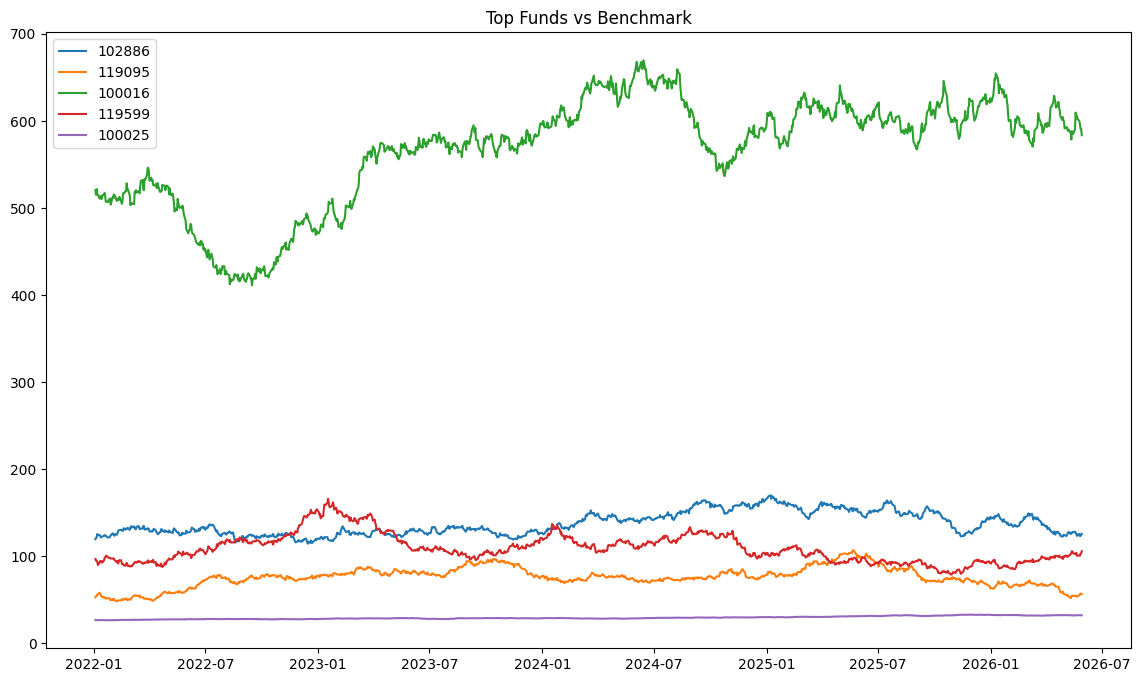

In [40]:
plt.figure(figsize=(14,8))

for fund in top5['fund']:

    temp = nav[
        nav['amfi_code']==fund
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=fund
    )

plt.legend()

plt.title(
    'Top Funds vs Benchmark'
)

plt.savefig(
    'benchmark_comparison.png'
)

plt.show()

In [42]:
tracking = []

for fund in top5['fund']:

    temp = nav[
        nav['amfi_code']==fund
    ]

    merged = pd.merge(
        temp,
        nifty100,
        on='date'
    )

    active = (
        merged['daily_return']
        -
        merged['benchmark_return']
    )

    # Ensure there are enough valid data points to calculate standard deviation
    if len(active.dropna()) > 1:
        te = (
            active.std()
            *
            np.sqrt(252)
        )
    else:
        te = np.nan # Assign NaN if not enough data to calculate

    tracking.append(
        [fund,te]
    )

tracking_df = pd.DataFrame(
    tracking,
    columns=[
        'fund',
        'tracking_error'
    ]
)

tracking_df

,fund,tracking_error
0,102886,0.225608
1,119095,0.285781
2,100016,0.199284
3,119599,0.277135
4,100025,0.134535
